In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

data = pd.read_csv('D:\work\Github\Customer_segmentations\Simple Segmentation\marketing_campaign.csv', delimiter="\t")
pd.set_option("display.max_columns", None)

data.head()

<>:26: SyntaxWarning: invalid escape sequence '\w'
<>:26: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Qamar Hasan\AppData\Local\Temp\ipykernel_3076\836780568.py:26: SyntaxWarning: invalid escape sequence '\w'
  data = pd.read_csv('D:\work\Github\Customer_segmentations\Simple Segmentation\marketing_campaign.csv', delimiter="\t")


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [5]:
data.info()

data = data.drop(columns=["ID", "Z_CostContact", "Z_Revenue", ])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:

# Combine Kidhome + Teenhome
data["children"] = data["Kidhome"] + data["Teenhome"]
data['Has_Children'] = (data['children'] > 0).astype(int)

# Convert join date, calculate Age
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
data['Age'] = data['Dt_Customer'].max().year - data['Year_Birth']
data['Age'] = data['Age'].clip(lower=18, upper=73)

# Age bins
age_bins = [18, 25, 45, 65, 73]
age_labels = [
    "Young Trend Seekers (18–25)",
    "Value-Oriented Adults (26–45)",
    "Mid-Lifers (46–65)",
    "Mature Elite Shoppers (65+)"
]

data['AgeGroup_Label'] = pd.cut(
    data['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

age_map = {
    "Young Trend Seekers (18–25)": 0,
    "Value-Oriented Adults (26–45)": 1,
    "Mid-Lifers (46–65)": 2,
    "Mature Elite Shoppers (65+)": 3
}
data['AgeGroup'] = data['AgeGroup_Label'].map(age_map)

# Marital Status cleanup + binning
data['Marital_Status'] = data['Marital_Status'].replace({
    'Married': 'In Relationship',
    'Together': 'In Relationship',
    'Single': 'Single',
    'Divorced': 'Single',
    'Widow': 'Single',
})
data = data[~data['Marital_Status'].isin(['Alone', 'Absurd','YOLO'])].copy()
data['Marital_Status'] = data['Marital_Status'].map({
    'In Relationship': 1,
    'Single': 0
})

# Purchases / Spending / Campaigns
data["Purchases"] =  data[[
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases"
]].sum(axis=1)
data["Spending"] = data[[
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"
]].sum(axis=1)
data["Effective_Campaigns"] = data[[
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"
]].sum(axis=1)

# Education binning
data['Education'] = data['Education'].replace(
    ['PhD', 'Master', "Graduation"], "Graduated"
)
le_education = LabelEncoder()
data['Education_Encoded'] = le_education.fit_transform(data['Education'])

In [7]:
# --- Drop only unused columns (KEEP NumWebVisitsMonth) ---
data = data.drop(columns=[
    "Kidhome", "Teenhome",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5",
    "Year_Birth","Dt_Customer","Education", "Age"
])



In [8]:
data.head()

,Marital_Status,Income,Recency,NumWebVisitsMonth,Complain,Response,children,Has_Children,AgeGroup_Label,AgeGroup,Purchases,Spending,Effective_Campaigns,Education_Encoded
0,0,58138.0,58,7,0,1,0,0,Mid-Lifers (46–65),2,25,1617,0,2
1,0,46344.0,38,5,0,0,2,1,Mid-Lifers (46–65),2,6,27,0,2
2,1,71613.0,26,4,0,0,0,0,Mid-Lifers (46–65),2,21,776,0,2
3,1,26646.0,26,6,0,0,1,1,Value-Oriented Adults (26–45),1,8,53,0,2
4,1,58293.0,94,5,0,0,1,1,Value-Oriented Adults (26–45),1,19,422,0,2


In [9]:
# --- Feature Groups ---
demo_features = ["AgeGroup", "Education_Encoded", "Marital_Status", "Income", "Has_Children"]
behavior_features = ["Purchases", "Spending"]  # ✅ kept
loyalty_features = ["Recency", "Response"]

cluster_features = behavior_features + loyalty_features



In [10]:
# Scale + Cluster
X = data[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



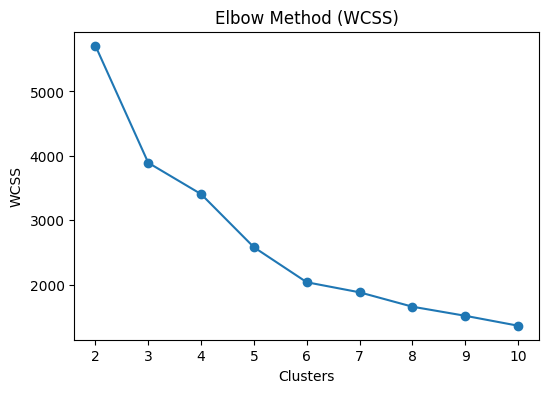

In [11]:
wcss, sil_scores = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow
plt.figure(figsize=(6,4))
plt.plot(range(2,11), wcss, marker="o")
plt.title("Elbow Method (WCSS)")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()


In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, data["Cluster"])
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: 0.417


In [13]:
# Save
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [14]:
cluster_profiles = data.groupby("Cluster")[cluster_features].mean()
print(cluster_profiles)

cluster_labels = {
    0: "High Spenders",
    1: "Budget-Conscious",
    2: "Trend Seekers",
    3: "Loyal Mid-Lifers"
}
data["Cluster_Label"] = data["Cluster"].map(cluster_labels)

         Purchases     Spending    Recency  Response
Cluster                                             
0        21.704762  1060.332143  52.569048       0.0
1         8.545198   126.370998  50.775895       0.0
2        12.045113   233.691729  28.203008       1.0
3        21.540404  1500.095960  40.247475       1.0


In [18]:
print("Cluster sizes:\n", data["Cluster"].value_counts())
print("\nCluster means:\n", data.groupby("Cluster")[cluster_features].mean())

# --- Numeric summary ---
numeric_demo = [col for col in demo_features if pd.api.types.is_numeric_dtype(data[col])]
numeric_summary = data.groupby("Cluster")[numeric_demo].mean()

# Cluster features (behavior + loyalty)
cluster_means = data.groupby("Cluster")[cluster_features].mean()

# Combine numeric profiles
cluster_profile = pd.concat([cluster_means, numeric_summary], axis=1)
print("\nCluster numeric profile (means):")
print(cluster_profile)

# --- Categorical summary ---
categorical_demo = [col for col in demo_features if col not in numeric_demo]
print("\nCluster categorical profile (proportions):")
for col in categorical_demo:
    print(f"\n{col}:")
    print(data.groupby("Cluster")[col].value_counts(normalize=True).unstack().round(2))


Cluster sizes:
 Cluster
1    1062
0     840
3     198
2     133
Name: count, dtype: int64

Cluster means:
          Purchases     Spending    Recency  Response
Cluster                                             
0        21.704762  1060.332143  52.569048       0.0
1         8.545198   126.370998  50.775895       0.0
2        12.045113   233.691729  28.203008       1.0
3        21.540404  1500.095960  40.247475       1.0

Cluster numeric profile (means):
         Purchases     Spending    Recency  Response  Education_Encoded  \
Cluster                                                                   
0        21.704762  1060.332143  52.569048       0.0           1.836905   
1         8.545198   126.370998  50.775895       0.0           1.739171   
2        12.045113   233.691729  28.203008       1.0           1.849624   
3        21.540404  1500.095960  40.247475       1.0           1.868687   

         Marital_Status        Income  Has_Children  
Cluster                             

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = data[demo_features + behavior_features + loyalty_features]
y = data["Cluster"]

# 1️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ Select numeric features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# 3️⃣ Preprocessing
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features)]
)

# 4️⃣ Define multiple models
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=2,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# 5️⃣ Train and evaluate each model
for name, model in models.items():
    print(f"\n===== {name} =====")
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    clf.fit(X_train, y_train)

    # Test set evaluation
    y_pred = clf.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Cross-validation
    cv_scores = cross_val_score(clf, X, y, cv=5)
    print("\nCross-Validation Scores:", cv_scores)
    print("Mean CV Accuracy:", cv_scores.mean())


===== RandomForest =====
Test Accuracy: 0.9910514541387024

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       168
           1       1.00      1.00      1.00       212
           2       0.93      0.96      0.95        27
           3       0.97      0.95      0.96        40

    accuracy                           0.99       447
   macro avg       0.97      0.98      0.98       447
weighted avg       0.99      0.99      0.99       447


Confusion Matrix:
 [[168   0   0   0]
 [  1 211   0   0]
 [  0   0  26   1]
 [  0   0   2  38]]

Cross-Validation Scores: [0.98657718 0.99105145 0.99776286 0.99775785 0.98430493]
Mean CV Accuracy: 0.9914908558300979

===== GradientBoosting =====


ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
sample_customers = pd.DataFrame([
    {
        "Income": 60000,
        "AgeGroup": 1,
        "Marital_Status": 1,
        "Education_Encoded": 1,
        "children": 0,
        "Has_Children": 0,
        "Purchases": 15,
        "Spending": 950,
        "Effective_Campaigns": 2,
        "Recency": 10,
        "Response": 1,
        "NumWebVisitsMonth": 5
    },
    {
        "Income": 20000,
        "AgeGroup": 0,
        "Marital_Status": 0,
        "Education_Encoded": 0,
        "children": 2,
        "Has_Children": 1,
        "Purchases": 3,
        "Spending": 120,
        "Effective_Campaigns": 0,
        "Recency": 80,
        "Response": 0,
        "NumWebVisitsMonth": 12
    }
])

# Predict clusters
pred_clusters = clf.predict(sample_customers)
sample_customers["Predicted_Cluster"] = pred_clusters
sample_customers["Cluster_Label"] = sample_customers["Predicted_Cluster"].map(cluster_labels)

print(sample_customers[[
    "Income", "AgeGroup", "Purchases", "Spending", "Predicted_Cluster", "Cluster_Label"
]])


   Income  AgeGroup  Purchases  Spending  Predicted_Cluster     Cluster_Label
0   60000         1         15       950                  2     Trend Seekers
1   20000         0          3       120                  1  Budget-Conscious
